# Imports

In [3]:
import torch.nn as nn
import torch
import torch.nn.functional as F

import cv2
import numpy as np

from scipy.spatial import distance
from scipy.interpolate import CubicSpline
from scipy import signal
from scipy.signal import savgol_filter, find_peaks

from tqdm import tqdm
import catboost as ctb
import pandas as pd

import matplotlib.pyplot as plt

from sympy import Line
from sympy.geometry.point import Point2D

import torchvision

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GroupKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from catboost import CatBoostClassifier
import joblib
import pickle

# Datasets and Models

Bounces Ground Truth https://www.kaggle.com/datasets/soykataminsapienza/tennis-bounces-gt

Homography Matrices and other stuff https://www.kaggle.com/datasets/soykataminsapienza/tennis-bounce-dataset

Rallies https://www.kaggle.com/datasets/soykataminsapienza/tennis-rallies/data

Checkpoints https://www.kaggle.com/models/soykataminsapienza/tennismodels/pyTorch/default/1


# Configuration

In [ ]:
# --- CONFIGURATION ---

device = 'cuda' if torch.cuda.is_available() else 'cpu'

PATH_BALL_MODEL = '/kaggle/input/tennismodels/pytorch/default/1/model_best (1).pt' 
PATH_COURT_MODEL = '/kaggle/input/tennismodels/pytorch/default/1/model_tennis_court_det.pt'
PATH_BOUNCE_MODEL = '/kaggle/input/tennismodels/pytorch/default/1/ctb_regr_bounce.cbm'

VIDEO_PATH1 = '/kaggle/input/tennis-rallies/rally_1.mp4'
VIDEO_PATH2 = '/kaggle/input/tennis-rallies/rally_2.mp4'
VIDEO_PATH3 = '/kaggle/input/tennis-rallies/rally_3.mp4'
VIDEO_PATH4 = '/kaggle/input/tennis-rallies/rally_4.mp4'
VIDEO_PATH5 = '/kaggle/input/tennis-rallies/rally_5.mp4' 
VIDEO_PATH6 = '/kaggle/input/tennis-rallies/rally_6.mp4'
VIDEO_PATH7 = '/kaggle/input/tennis-rallies/rally_7v2.mp4'
VIDEO_PATH8 = '/kaggle/input/tennis-rallies/rally_8.mp4'

BALL_PATH1 = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels1.csv'
BALL_PATH2 = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels2.csv'
BALL_PATH3 = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels3.csv'
BALL_PATH4 = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels4.csv'
BALL_PATH5 = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels5.csv'
BALL_PATH6 = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels6.csv'
BALL_PATH7 = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels7.csv'
BALL_PATH8 = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels8.csv'

GT_PATH1 = '/kaggle/input/tennis-bounces-gt/manual_ground_truth1.csv'
GT_PATH2 = '/kaggle/input/tennis-bounces-gt/manual_ground_truth2.csv'
GT_PATH3 = '/kaggle/input/tennis-bounces-gt/manual_ground_truth3.csv'
GT_PATH4 = '/kaggle/input/tennis-bounces-gt/manual_ground_truth4.csv'
GT_PATH5 = '/kaggle/input/tennis-bounces-gt/manual_ground_truth5.csv'
GT_PATH6 = '/kaggle/input/tennis-bounces-gt/manual_ground_truth6.csv'
GT_PATH7 = '/kaggle/input/tennis-bounces-gt/manual_ground_truth7.csv'
GT_PATH8 = '/kaggle/input/tennis-bounces-gt/manual_ground_truth8.csv'

PLAYER_PATH1 = '/kaggle/input/tennis-bounce-dataset/player_tracks1.csv'
PLAYER_PATH2 = '/kaggle/input/tennis-bounce-dataset/player_tracks2.csv'
PLAYER_PATH3 = '/kaggle/input/tennis-bounce-dataset/player_tracks3.csv'
PLAYER_PATH4 = '/kaggle/input/tennis-bounce-dataset/player_tracks4.csv'
PLAYER_PATH5 = '/kaggle/input/tennis-bounce-dataset/player_tracks5.csv'
PLAYER_PATH6 = '/kaggle/input/tennis-bounce-dataset/player_tracks6.csv'
PLAYER_PATH7 = '/kaggle/input/tennis-bounce-dataset/player_tracks7.csv'
PLAYER_PATH8 = '/kaggle/input/tennis-bounce-dataset/player_tracks8.csv'

MODEL_PATH_NEW = '/kaggle/working/smart_bounce_model_catboost.pkl'
MODEL_PATH_OLD = '/kaggle/input/tennismodels/pytorch/default/1/ctb_regr_bounce.cbm'

# INPUTS
NEW_TRACK_PATH = '/kaggle/input/tennis-bounce-dataset/ball_track_pixels8.csv'
GT_PATH = '/kaggle/input/tennis-bounces-gt/manual_ground_truth8.csv'
PLAYER_PATH = '/kaggle/input/tennis-bounce-dataset/player_tracks8.csv'
MATRICES_PATH = '/kaggle/input/tennis-bounce-dataset/video8_matrices.npy'

# SHIFT (If needed for sync)
FRAME_SHIFT = 0 

# TrackNet

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, pad=1, stride=1, bias=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=pad, bias=bias),
            nn.ReLU(),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        return self.block(x)

class BallTrackerNet(nn.Module):
    def __init__(self, input_channels=3, out_channels=14):
        super().__init__()
        self.out_channels = out_channels
        self.input_channels = input_channels

        self.conv1 = ConvBlock(in_channels=self.input_channels, out_channels=64)
        self.conv2 = ConvBlock(in_channels=64, out_channels=64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = ConvBlock(in_channels=64, out_channels=128)
        self.conv4 = ConvBlock(in_channels=128, out_channels=128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv5 = ConvBlock(in_channels=128, out_channels=256)
        self.conv6 = ConvBlock(in_channels=256, out_channels=256)
        self.conv7 = ConvBlock(in_channels=256, out_channels=256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv8 = ConvBlock(in_channels=256, out_channels=512)
        self.conv9 = ConvBlock(in_channels=512, out_channels=512)
        self.conv10 = ConvBlock(in_channels=512, out_channels=512)
        self.ups1 = nn.Upsample(scale_factor=2)
        self.conv11 = ConvBlock(in_channels=512, out_channels=256)
        self.conv12 = ConvBlock(in_channels=256, out_channels=256)
        self.conv13 = ConvBlock(in_channels=256, out_channels=256)
        self.ups2 = nn.Upsample(scale_factor=2)
        self.conv14 = ConvBlock(in_channels=256, out_channels=128)
        self.conv15 = ConvBlock(in_channels=128, out_channels=128)
        self.ups3 = nn.Upsample(scale_factor=2)
        self.conv16 = ConvBlock(in_channels=128, out_channels=64)
        self.conv17 = ConvBlock(in_channels=64, out_channels=64)
        self.conv18 = ConvBlock(in_channels=64, out_channels=self.out_channels)

        self._init_weights()
                  
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)    
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        x = self.pool3(x)
        x = self.conv8(x)
        x = self.conv9(x)
        x = self.conv10(x)
        x = self.ups1(x)
        x = self.conv11(x)
        x = self.conv12(x)
        x = self.conv13(x)
        x = self.ups2(x)
        x = self.conv14(x)
        x = self.conv15(x)
        x = self.ups3(x)
        x = self.conv16(x)
        x = self.conv17(x)
        x = self.conv18(x)
        return x
    
    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.uniform_(module.weight, -0.05, 0.05)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)   

# Ball Detection

In [4]:
class BallDetector:
    def __init__(self, path_model=None, device='cuda'):
        self.model = BallTrackerNet(input_channels=9, out_channels=256)
        self.device = device
        if path_model:
            self.model.load_state_dict(torch.load(path_model, map_location=device))
            self.model = self.model.to(device)
            self.model.eval()
        self.width = 640
        self.height = 360

    def infer_model(self, frames):
        """ Run pretrained model on a consecutive list of frames
        :params
            frames: list of consecutive video frames
        :return
            ball_track: list of detected ball points
        """
        ball_track = [(None, None)]*2
        prev_pred = [None, None]
        for num in tqdm(range(2, len(frames))):
            img = cv2.resize(frames[num], (self.width, self.height))
            img_prev = cv2.resize(frames[num-1], (self.width, self.height))
            img_preprev = cv2.resize(frames[num-2], (self.width, self.height))
            imgs = np.concatenate((img, img_prev, img_preprev), axis=2)
            imgs = imgs.astype(np.float32)/255.0
            imgs = np.rollaxis(imgs, 2, 0)
            inp = np.expand_dims(imgs, axis=0)

            out = self.model(torch.from_numpy(inp).float().to(self.device))
            output = out.argmax(dim=1).detach().cpu().numpy()
            x_pred, y_pred = self.postprocess(output, prev_pred)
            prev_pred = [x_pred, y_pred]
            ball_track.append((x_pred, y_pred))
        return ball_track

    def postprocess(self, feature_map, prev_pred, scale=2, max_dist=80):
        """
        :params
            feature_map: feature map with shape (1,360,640)
            prev_pred: [x,y] coordinates of ball prediction from previous frame
            scale: scale for conversion to original shape (720,1280)
            max_dist: maximum distance from previous ball detection to remove outliers
        :return
            x,y ball coordinates
        """
        feature_map *= 255
        feature_map = feature_map.reshape((self.height, self.width))
        feature_map = feature_map.astype(np.uint8)
        ret, heatmap = cv2.threshold(feature_map, 127, 255, cv2.THRESH_BINARY)
        circles = cv2.HoughCircles(heatmap, cv2.HOUGH_GRADIENT, dp=1, minDist=1, param1=50, param2=2, minRadius=2,
                                   maxRadius=7)
        x, y = None, None
        if circles is not None:
            if prev_pred[0]:
                for i in range(len(circles[0])):
                    x_temp = circles[0][i][0]*scale
                    y_temp = circles[0][i][1]*scale
                    dist = distance.euclidean((x_temp, y_temp), prev_pred)
                    if dist < max_dist:
                        x, y = x_temp, y_temp
                        break                
            else:
                x = circles[0][0][0]*scale
                y = circles[0][0][1]*scale
        return x, y

# Bounce detector

In [5]:
class BounceDetector:
    def __init__(self, path_model=None):
        self.model = ctb.CatBoostRegressor()
        self.threshold = 0.45
        if path_model:
            self.load_model(path_model)
        
    def load_model(self, path_model):
        self.model.load_model(path_model)
    
    def prepare_features(self, x_ball, y_ball):
        labels = pd.DataFrame({'frame': range(len(x_ball)), 'x-coordinate': x_ball, 'y-coordinate': y_ball})
        
        num = 3
        eps = 1e-15
        for i in range(1, num):
            labels['x_lag_{}'.format(i)] = labels['x-coordinate'].shift(i)
            labels['x_lag_inv_{}'.format(i)] = labels['x-coordinate'].shift(-i)
            labels['y_lag_{}'.format(i)] = labels['y-coordinate'].shift(i)
            labels['y_lag_inv_{}'.format(i)] = labels['y-coordinate'].shift(-i) 
            labels['x_diff_{}'.format(i)] = abs(labels['x_lag_{}'.format(i)] - labels['x-coordinate'])
            labels['y_diff_{}'.format(i)] = labels['y_lag_{}'.format(i)] - labels['y-coordinate']
            labels['x_diff_inv_{}'.format(i)] = abs(labels['x_lag_inv_{}'.format(i)] - labels['x-coordinate'])
            labels['y_diff_inv_{}'.format(i)] = labels['y_lag_inv_{}'.format(i)] - labels['y-coordinate']
            labels['x_div_{}'.format(i)] = abs(labels['x_diff_{}'.format(i)]/(labels['x_diff_inv_{}'.format(i)] + eps))
            labels['y_div_{}'.format(i)] = labels['y_diff_{}'.format(i)]/(labels['y_diff_inv_{}'.format(i)] + eps)

        for i in range(1, num):
            labels = labels[labels['x_lag_{}'.format(i)].notna()]
            labels = labels[labels['x_lag_inv_{}'.format(i)].notna()]
        labels = labels[labels['x-coordinate'].notna()] 
        
        colnames_x = ['x_diff_{}'.format(i) for i in range(1, num)] + \
                     ['x_diff_inv_{}'.format(i) for i in range(1, num)] + \
                     ['x_div_{}'.format(i) for i in range(1, num)]
        colnames_y = ['y_diff_{}'.format(i) for i in range(1, num)] + \
                     ['y_diff_inv_{}'.format(i) for i in range(1, num)] + \
                     ['y_div_{}'.format(i) for i in range(1, num)]
        colnames = colnames_x + colnames_y

        features = labels[colnames]
        return features, list(labels['frame'])
    
    def predict(self, x_ball, y_ball, smooth=True):
        if smooth:
            x_ball, y_ball = self.smooth_predictions(x_ball, y_ball)
        features, num_frames = self.prepare_features(x_ball, y_ball)
        preds = self.model.predict(features)
        ind_bounce = np.where(preds > self.threshold)[0]
        if len(ind_bounce) > 0:
            ind_bounce = self.postprocess(ind_bounce, preds)
        frames_bounce = [num_frames[x] for x in ind_bounce]
        return set(frames_bounce)
    
    def smooth_predictions(self, x_ball, y_ball):
        is_none = [int(x is None) for x in x_ball]
        interp = 5
        counter = 0
        for num in range(interp, len(x_ball)-1):
            if not x_ball[num] and sum(is_none[num-interp:num]) == 0 and counter < 3:
                x_ext, y_ext = self.extrapolate(x_ball[num-interp:num], y_ball[num-interp:num])
                x_ball[num] = x_ext
                y_ball[num] = y_ext
                is_none[num] = 0
                if x_ball[num+1]:
                    dist = distance.euclidean((x_ext, y_ext), (x_ball[num+1], y_ball[num+1]))
                    if dist > 80:
                        x_ball[num+1], y_ball[num+1], is_none[num+1] = None, None, 1
                counter += 1
            else:
                counter = 0  
        return x_ball, y_ball

    def extrapolate(self, x_coords, y_coords):
        xs = list(range(len(x_coords)))
        func_x = CubicSpline(xs, x_coords, bc_type='natural')
        x_ext = func_x(len(x_coords))
        func_y = CubicSpline(xs, y_coords, bc_type='natural')
        y_ext = func_y(len(x_coords))
        return float(x_ext), float(y_ext)    

    def postprocess(self, ind_bounce, preds):
        ind_bounce_filtered = [ind_bounce[0]]
        for i in range(1, len(ind_bounce)):
            if (ind_bounce[i] - ind_bounce[i-1]) != 1:
                cur_ind = ind_bounce[i]
                ind_bounce_filtered.append(cur_ind)
            elif preds[ind_bounce[i]] > preds[ind_bounce[i-1]]:
                ind_bounce_filtered[-1] = ind_bounce[i]
        return ind_bounce_filtered

# Court reference

In [6]:
class CourtReference:
    """
    Court reference model
    """
    def __init__(self):
        self.baseline_top = ((286, 561), (1379, 561))
        self.baseline_bottom = ((286, 2935), (1379, 2935))
        self.net = ((286, 1748), (1379, 1748))
        self.left_court_line = ((286, 561), (286, 2935))
        self.right_court_line = ((1379, 561), (1379, 2935))
        self.left_inner_line = ((423, 561), (423, 2935))
        self.right_inner_line = ((1242, 561), (1242, 2935))
        self.middle_line = ((832, 1110), (832, 2386))
        self.top_inner_line = ((423, 1110), (1242, 1110))
        self.bottom_inner_line = ((423, 2386), (1242, 2386))
        self.top_extra_part = (832.5, 580)
        self.bottom_extra_part = (832.5, 2910)
        
        self.key_points = [*self.baseline_top, *self.baseline_bottom, 
                          *self.left_inner_line, *self.right_inner_line,
                          *self.top_inner_line, *self.bottom_inner_line,
                          *self.middle_line]
        
        self.border_points = [*self.baseline_top, *self.baseline_bottom[::-1]]

        self.court_conf = {1: [*self.baseline_top, *self.baseline_bottom],
                           2: [self.left_inner_line[0], self.right_inner_line[0], self.left_inner_line[1],
                               self.right_inner_line[1]],
                           3: [self.left_inner_line[0], self.right_court_line[0], self.left_inner_line[1],
                               self.right_court_line[1]],
                           4: [self.left_court_line[0], self.right_inner_line[0], self.left_court_line[1],
                               self.right_inner_line[1]],
                           5: [*self.top_inner_line, *self.bottom_inner_line],
                           6: [*self.top_inner_line, self.left_inner_line[1], self.right_inner_line[1]],
                           7: [self.left_inner_line[0], self.right_inner_line[0], *self.bottom_inner_line],
                           8: [self.right_inner_line[0], self.right_court_line[0], self.right_inner_line[1],
                               self.right_court_line[1]],
                           9: [self.left_court_line[0], self.left_inner_line[0], self.left_court_line[1],
                               self.left_inner_line[1]],
                           10: [self.top_inner_line[0], self.middle_line[0], self.bottom_inner_line[0],
                                self.middle_line[1]],
                           11: [self.middle_line[0], self.top_inner_line[1], self.middle_line[1],
                                self.bottom_inner_line[1]],
                           12: [*self.bottom_inner_line, self.left_inner_line[1], self.right_inner_line[1]]}
        self.line_width = 1
        self.court_width = 1117
        self.court_height = 2408
        self.top_bottom_border = 549
        self.right_left_border = 274
        self.court_total_width = self.court_width + self.right_left_border * 2
        self.court_total_height = self.court_height + self.top_bottom_border * 2
        self.court = self.build_court_reference()

        # self.court = cv2.cvtColor(cv2.imread('court_configurations/court_reference.png'), cv2.COLOR_BGR2GRAY)

    def build_court_reference(self):
        """
        Create court reference image using the lines positions
        """
        court = np.zeros((self.court_height + 2 * self.top_bottom_border, self.court_width + 2 * self.right_left_border), dtype=np.uint8)
        cv2.line(court, *self.baseline_top, 1, self.line_width)
        cv2.line(court, *self.baseline_bottom, 1, self.line_width)
        cv2.line(court, *self.net, 1, self.line_width)
        cv2.line(court, *self.top_inner_line, 1, self.line_width)
        cv2.line(court, *self.bottom_inner_line, 1, self.line_width)
        cv2.line(court, *self.left_court_line, 1, self.line_width)
        cv2.line(court, *self.right_court_line, 1, self.line_width)
        cv2.line(court, *self.left_inner_line, 1, self.line_width)
        cv2.line(court, *self.right_inner_line, 1, self.line_width)
        cv2.line(court, *self.middle_line, 1, self.line_width)
        court = cv2.dilate(court, np.ones((5, 5), dtype=np.uint8))
        # court = cv2.dilate(court, np.ones((7, 7), dtype=np.uint8))
        # plt.imsave('court_configurations/court_reference.png', court, cmap='gray')
        # self.court = court
        return court

    def get_important_lines(self):
        """
        Returns all lines of the court
        """
        lines = [*self.baseline_top, *self.baseline_bottom, *self.net, *self.left_court_line, *self.right_court_line,
                 *self.left_inner_line, *self.right_inner_line, *self.middle_line,
                 *self.top_inner_line, *self.bottom_inner_line]
        return lines

    def get_extra_parts(self):
        parts = [self.top_extra_part, self.bottom_extra_part]
        return parts

    def save_all_court_configurations(self):
        """
        Create all configurations of 4 points on court reference
        """
        for i, conf in self.court_conf.items():
            c = cv2.cvtColor(255 - self.court, cv2.COLOR_GRAY2BGR)
            for p in conf:
                c = cv2.circle(c, p, 15, (0, 0, 255), 30)
            cv2.imwrite(f'court_configurations/court_conf_{i}.png', c)

    def get_court_mask(self, mask_type=0):
        """
        Get mask of the court
        """
        mask = np.ones_like(self.court)
        if mask_type == 1:  # Bottom half court
            # mask[:self.net[0][1] - 1000, :] = 0
            mask[:self.net[0][1], :] = 0
        elif mask_type == 2:  # Top half court
            mask[self.net[0][1]:, :] = 0
        elif mask_type == 3: # court without margins
            mask[:self.baseline_top[0][1], :] = 0
            mask[self.baseline_bottom[0][1]:, :] = 0
            mask[:, :self.left_court_line[0][0]] = 0
            mask[:, self.right_court_line[0][0]:] = 0
        return mask


if __name__ == '__main__':
    c = CourtReference()
    c.build_court_reference()

# Homography

In [7]:
court_ref = CourtReference()
refer_kps = np.array(court_ref.key_points, dtype=np.float32).reshape((-1, 1, 2))

court_conf_ind = {}
for i in range(len(court_ref.court_conf)):
    conf = court_ref.court_conf[i+1]
    inds = []
    for j in range(4):
        inds.append(court_ref.key_points.index(conf[j]))
    court_conf_ind[i+1] = inds

def get_trans_matrix(points):
    """
    Determine the best homography matrix from court points
    """
    matrix_trans = None
    dist_max = np.inf
    for conf_ind in range(1, 13):
        conf = court_ref.court_conf[conf_ind]

        inds = court_conf_ind[conf_ind]
        inters = [points[inds[0]], points[inds[1]], points[inds[2]], points[inds[3]]]
        if None not in inters:
            matrix, _ = cv2.findHomography(np.float32(conf), np.float32(inters), method=0)
            trans_kps = cv2.perspectiveTransform(refer_kps, matrix).squeeze(1)
            dists = []
            for i in range(12):
                if i not in inds and points[i] is not None:
                    dists.append(distance.euclidean(points[i], trans_kps[i]))
            dist_median = np.mean(dists)
            if dist_median < dist_max:
                matrix_trans = matrix
                dist_max = dist_median
    return matrix_trans 

# Postprocess

In [8]:
def line_intersection(line1, line2):
    """
    Find 2 lines intersection point
    """
    l1 = Line((line1[0], line1[1]), (line1[2], line1[3]))
    l2 = Line((line2[0], line2[1]), (line2[2], line2[3]))

    intersection = l1.intersection(l2)
    point = None
    if len(intersection) > 0:
        if isinstance(intersection[0], Point2D):
            point = intersection[0].coordinates
    return point 

def refine_kps(img, x_ct, y_ct, crop_size=40):
    refined_x_ct, refined_y_ct = x_ct, y_ct
    
    img_height, img_width = img.shape[:2]
    x_min = max(x_ct-crop_size, 0)
    x_max = min(img_height, x_ct+crop_size)
    y_min = max(y_ct-crop_size, 0)
    y_max = min(img_width, y_ct+crop_size)

    img_crop = img[x_min:x_max, y_min:y_max]
    lines = detect_lines(img_crop)
    # print('lines = ', lines)
    
    if len(lines) > 1:
        lines = merge_lines(lines)
        if len(lines) == 2:
            inters = line_intersection(lines[0], lines[1])
            if inters:
                new_x_ct = int(inters[1])
                new_y_ct = int(inters[0])
                if new_x_ct > 0 and new_x_ct < img_crop.shape[0] and new_y_ct > 0 and new_y_ct < img_crop.shape[1]:
                    refined_x_ct = x_min + new_x_ct
                    refined_y_ct = y_min + new_y_ct                    
    return refined_y_ct, refined_x_ct

def detect_lines(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.threshold(gray, 155, 255, cv2.THRESH_BINARY)[1]
    lines = cv2.HoughLinesP(gray, 1, np.pi / 180, 30, minLineLength=10, maxLineGap=30)
    lines = np.squeeze(lines) 
    if len(lines.shape) > 0:
        if len(lines) == 4 and not isinstance(lines[0], np.ndarray):
            lines = [lines]
    else:
        lines = []
    return lines

def merge_lines(lines):
    lines = sorted(lines, key=lambda item: item[0])
    mask = [True] * len(lines)
    new_lines = []

    for i, line in enumerate(lines):
        if mask[i]:
            for j, s_line in enumerate(lines[i + 1:]):
                if mask[i + j + 1]:
                    x1, y1, x2, y2 = line
                    x3, y3, x4, y4 = s_line
                    dist1 = distance.euclidean((x1, y1), (x3, y3))
                    dist2 = distance.euclidean((x2, y2), (x4, y4))
                    if dist1 < 20 and dist2 < 20:
                        line = np.array([int((x1+x3)/2), int((y1+y3)/2), int((x2+x4)/2), int((y2+y4)/2)])
                        mask[i + j + 1] = False
            new_lines.append(line)  
    return new_lines       

# Court detection net

In [9]:
class CourtDetectorNet():
    def __init__(self, path_model=None,  device='cuda'):
        self.model = BallTrackerNet(out_channels=15)
        self.device = device
        if path_model:
            self.model.load_state_dict(torch.load(path_model, map_location=device))
            self.model = self.model.to(device)
            self.model.eval()
            
    def infer_model(self, frames):
        output_width = 640
        output_height = 360
        scale = 2
        
        kps_res = []
        matrixes_res = []
        for num_frame, image in enumerate(tqdm(frames)):
            img = cv2.resize(image, (output_width, output_height))
            inp = (img.astype(np.float32) / 255.)
            inp = torch.tensor(np.rollaxis(inp, 2, 0))
            inp = inp.unsqueeze(0)

            out = self.model(inp.float().to(self.device))[0]
            pred = F.sigmoid(out).detach().cpu().numpy()

            points = []
            for kps_num in range(14):
                heatmap = (pred[kps_num]*255).astype(np.uint8)
                ret, heatmap = cv2.threshold(heatmap, 170, 255, cv2.THRESH_BINARY)
                circles = cv2.HoughCircles(heatmap, cv2.HOUGH_GRADIENT, dp=1, minDist=20, param1=50, param2=2,
                                           minRadius=10, maxRadius=25)
                if circles is not None:
                    x_pred = circles[0][0][0]*scale
                    y_pred = circles[0][0][1]*scale
                    if kps_num not in [8, 12, 9]:
                        x_pred, y_pred = refine_kps(image, int(y_pred), int(x_pred), crop_size=40)
                    points.append((x_pred, y_pred))                
                else:
                    points.append(None)

            matrix_trans = get_trans_matrix(points) 
            points = None
            if matrix_trans is not None:
                points = cv2.perspectiveTransform(refer_kps, matrix_trans)
                matrix_trans = cv2.invert(matrix_trans)[1]
            kps_res.append(points)
            matrixes_res.append(matrix_trans)
            
        return matrixes_res, kps_res    

# Person detector

In [10]:
class PersonDetector:
    def __init__(self, device='cuda'):
        self.detection_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
        self.device = device
        self.detection_model = self.detection_model.to(self.device)
        self.detection_model.eval()
        
        self.court_ref = CourtReference()
        self.ref_top_court = self.court_ref.get_court_mask(2)
        self.ref_bottom_court = self.court_ref.get_court_mask(1)

    def detect(self, image, person_min_score=0.85): 
        PERSON_LABEL = 1
        frame_tensor = image.transpose((2, 0, 1)) / 255
        frame_tensor = torch.from_numpy(frame_tensor).unsqueeze(0).float().to(self.device)
        
        with torch.no_grad():
            preds = self.detection_model(frame_tensor)
            
        persons_boxes = []
        for box, label, score in zip(preds[0]['boxes'][:], preds[0]['labels'], preds[0]['scores']):
            if label == PERSON_LABEL and score > person_min_score:    
                persons_boxes.append(box.detach().cpu().numpy())
        return persons_boxes

    def detect_top_and_bottom_players(self, image, inv_matrix, filter_players=False):
        # --- FIX IS HERE ---
        # Force the matrix to be float32, preventing the "object is not supported" error
        inv_matrix = np.array(inv_matrix).astype(np.float32)
        
        matrix = cv2.invert(inv_matrix)[1]
        mask_top_court = cv2.warpPerspective(self.ref_top_court, matrix, image.shape[1::-1])
        mask_bottom_court = cv2.warpPerspective(self.ref_bottom_court, matrix, image.shape[1::-1])
        person_bboxes_top, person_bboxes_bottom = [], []

        bboxes = self.detect(image, person_min_score=0.85)
        if len(bboxes) > 0:
            person_points = [[int((bbox[2] + bbox[0]) / 2), int(bbox[3])] for bbox in bboxes]
            person_bboxes = list(zip(bboxes, person_points))
  
            person_bboxes_top = [pt for pt in person_bboxes if mask_top_court[pt[1][1]-1, pt[1][0]] == 1]
            person_bboxes_bottom = [pt for pt in person_bboxes if mask_bottom_court[pt[1][1] - 1, pt[1][0]] == 1]

            if filter_players:
                person_bboxes_top, person_bboxes_bottom = self.filter_players(person_bboxes_top, person_bboxes_bottom, matrix)
        return person_bboxes_top, person_bboxes_bottom

    def filter_players(self, person_bboxes_top, person_bboxes_bottom, matrix):
        refer_kps = np.array(self.court_ref.key_points[12:], dtype=np.float32).reshape((-1, 1, 2))
        trans_kps = cv2.perspectiveTransform(refer_kps, matrix)
        center_top_court = trans_kps[0][0]
        center_bottom_court = trans_kps[1][0]
        
        if len(person_bboxes_top) > 1:
            dists = [distance.euclidean(x[1], center_top_court) for x in person_bboxes_top]
            ind = dists.index(min(dists))
            person_bboxes_top = [person_bboxes_top[ind]]
        if len(person_bboxes_bottom) > 1:
            dists = [distance.euclidean(x[1], center_bottom_court) for x in person_bboxes_bottom]
            ind = dists.index(min(dists))
            person_bboxes_bottom = [person_bboxes_bottom[ind]]
        return person_bboxes_top, person_bboxes_bottom
    
    def track_players(self, frames, matrix_all, filter_players=False):
        persons_top = []
        persons_bottom = []
        min_len = min(len(frames), len(matrix_all))
        for num_frame in tqdm(range(min_len)):
            img = frames[num_frame]
            if matrix_all[num_frame] is not None:
                inv_matrix = matrix_all[num_frame]
                person_top, person_bottom = self.detect_top_and_bottom_players(img, inv_matrix, filter_players)
            else:
                person_top, person_bottom = [], []
            persons_top.append(person_top)
            persons_bottom.append(person_bottom)
        return persons_top, persons_bottom

# Pixels to Meters

In [11]:
# --- HELPER: VIDEO LOADER ---
def read_video(path_video):
    cap = cv2.VideoCapture(path_video)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frames = []
    print(f"Reading video: {path_video}...")
    while cap.isOpened():
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
        else:
            break    
    cap.release()
    print(f"Loaded {len(frames)} frames.")
    return frames, fps

# --- CORE: COORDINATE CONVERTER ---
class PreciseCoordinateExtractor:
    """
    Converts pixel data from this specific repo's CourtReference 
    into real-world meters relative to the net.
    """
    def __init__(self):
        # Constants derived from the 'CourtReference' class in the repo
        # Top Baseline Y: 561, Bottom Baseline Y: 2935 -> Length in px: 2374
        # Real Tennis Court Length: 23.77 meters
        # Scale: ~99.87 pixels per meter. We'll use 100 for simplicity.
        self.px_per_meter = 100.0 
        
        # Center of the court in the reference image
        # X Center = (Left Line 286 + Right Line 1379) / 2 = 832.5
        # Y Center = Net Line = 1748
        self.ref_net_y = 1748
        self.ref_center_x = 832.5

    def get_coordinates(self, bounces, ball_track, homography_matrices, fps=30):
        data = []
        print("Extracting coordinates for detected bounces...")
        
        for frame_idx in sorted(list(bounces)):
            # 1. Get Ball Position
            ball_pos = ball_track[frame_idx]
            
            # Handle missing ball (look +/- 1 frame)
            if ball_pos[0] is None:
                if frame_idx > 0 and ball_track[frame_idx-1][0]: 
                    ball_pos = ball_track[frame_idx-1]
                elif frame_idx < len(ball_track)-1 and ball_track[frame_idx+1][0]:
                    ball_pos = ball_track[frame_idx+1]
                else:
                    continue # Skip if ball is lost
            
            # 2. Get Homography (Video -> Reference)
            # The repo's 'infer_model' returns the inverted matrix (Video -> Ref)
            inv_matrix = homography_matrices[frame_idx]
            
            if inv_matrix is not None:
                # 3. Project to Reference Image

                inv_matrix = np.array(inv_matrix, dtype=np.float32)
                
                pt_original = np.array([ball_pos], dtype='float32').reshape(1, 1, 2)
                pt_ref = cv2.perspectiveTransform(pt_original, inv_matrix)[0][0]
                
                # 4. Convert to Meters (Relative to Net)
                # Y: Negative = Far Court, Positive = Near Court
                real_y = (pt_ref[1] - self.ref_net_y) / self.px_per_meter
                # X: Negative = Left, Positive = Right
                real_x = (pt_ref[0] - self.ref_center_x) / self.px_per_meter
                
                # 5. Determine Zones
                depth = "Service Box" if abs(real_y) < 6.40 else ("Deep" if abs(real_y) < 11.89 else "Out")
                side = "Deuce" if (real_x * real_y) < 0 else "Ad" # Standard tennis logic

                data.append({
                    'frame': frame_idx,
                    'timestamp': frame_idx / fps,
                    'x_meters': round(real_x, 2),
                    'y_meters': round(real_y, 2),
                    'depth': depth,
                    'side': side
                })
        
        return pd.DataFrame(data)

In [12]:

# VIDEO_PATH = "/kaggle/input/tennis-rallies/rally_8.mp4"

# frames, fps = read_video(VIDEO_PATH)

# # 1. Detect Ball
# print("\n--- Step 1: Tracking Ball ---")
# ball_detector = BallDetector(PATH_BALL_MODEL, device)
# ball_track = ball_detector.infer_model(frames)

# # 2. Detect Court (Homography)
# print("\n--- Step 2: Mapping Court ---")
# court_detector = CourtDetectorNet(PATH_COURT_MODEL, device)
# homography_matrices, kps_court = court_detector.infer_model(frames)

# # 3. Detect Bounces
# print("\n--- Step 3: Detecting Bounces ---")
# bounce_detector = BounceDetector(PATH_BOUNCE_MODEL)
# x_ball = [x[0] for x in ball_track]
# y_ball = [x[1] for x in ball_track]
# bounces = bounce_detector.predict(x_ball, y_ball)

# # 4. Extract Final Coordinates
# print("\n--- Step 4: Generating Dataset ---")
# extractor = PreciseCoordinateExtractor()
# df_results = extractor.get_coordinates(bounces, ball_track, homography_matrices)

# # 5. Show and Save
# print("\nDONE! Here are the detected landing spots:")
# print(df_results)
# df_results.to_csv('tennis_landing_coordinates.csv', index=False)

# ball_data = []

# for i, (x, y) in enumerate(ball_track):
#     ball_data.append({
#         "frame": i,
#         "time_sec": i / fps,
#         "x_pixel": x,
#         "y_pixel": y,
#         "detected": x is not None
#     })

# df_ball = pd.DataFrame(ball_data)
# df_ball.to_csv("ball_track_pixels8.csv", index=False)

# Save person data

In [13]:
def extract_player_centroids(video_path, output_csv, matrices_path, device='cuda'):
    # A. Load Video
    frames, fps = read_video(video_path)
    
    # B. Load Matrices from .npy file
    print(f"Loading matrices from {matrices_path}...")
    homography_matrices = np.load(matrices_path, allow_pickle=True)
    
    # C. Detect Players
    print("Detecting players using saved matrices...")
    person_detector = PersonDetector(device=device)
    persons_top, persons_bottom = person_detector.track_players(frames, homography_matrices, filter_players=True)
    
    # D. Save to CSV
    data = []
    for i in range(len(frames)):
        p1_x, p1_y = np.nan, np.nan
        p2_x, p2_y = np.nan, np.nan
        
        # Top Player (P1)
        if len(persons_top[i]) > 0:
            box = persons_top[i][0][0]
            p1_x = (box[0] + box[2]) / 2
            p1_y = (box[1] + box[3]) / 2
            
        # Bottom Player (P2)
        if len(persons_bottom[i]) > 0:
            box = persons_bottom[i][0][0]
            p2_x = (box[0] + box[2]) / 2
            p2_y = (box[1] + box[3]) / 2
            
        data.append({
            'frame': i,
            'p1_x': p1_x, 'p1_y': p1_y,
            'p2_x': p2_x, 'p2_y': p2_y
        })
        
    df = pd.DataFrame(data)
    df.to_csv(output_csv, index=False)
    print(f"Saved player tracks to {output_csv}")

    
# extract_player_centroids(VIDEO_PATH1, 'player_tracks1.csv', '/kaggle/input/tennis-bounce-dataset/video1_matrices.npy')
# extract_player_centroids(VIDEO_PATH2, 'player_tracks2.csv', '/kaggle/input/tennis-bounce-dataset/video2_matrices.npy')
# extract_player_centroids(VIDEO_PATH3, 'player_tracks3.csv', '/kaggle/input/tennis-bounce-dataset/video3_matrices.npy')
# extract_player_centroids(VIDEO_PATH4, 'player_tracks4.csv', '/kaggle/input/tennis-bounce-dataset/video4_matrices.npy')
# extract_player_centroids(VIDEO_PATH5, 'player_tracks5.csv', '/kaggle/input/tennis-bounce-dataset/video5_matrices.npy')
# extract_player_centroids(VIDEO_PATH6, 'player_tracks6.csv', '/kaggle/input/tennis-bounce-dataset/video6_matrices.npy')
# extract_player_centroids(VIDEO_PATH7, 'player_tracks7.csv', '/kaggle/input/tennis-bounce-dataset/video7_matrices.npy')
# extract_player_centroids(VIDEO_PATH8, 'player_tracks8.csv', '/kaggle/input/tennis-bounce-dataset/video8_matrices.npy')

# Train Model

In [14]:
# ============================================================
# FEATURE EXTRACTION (BALL ONLY + AUGMENTATION)
# ============================================================

def extract_features_from_track(y_seq, x_seq, gt_frames):
    y_filled = pd.Series(y_seq).interpolate(limit_direction="both").values
    x_filled = pd.Series(x_seq).interpolate(limit_direction="both").values

    y_smooth = savgol_filter(y_filled, 3, 2)
    x_smooth = savgol_filter(x_filled, 3, 2)

    vy = np.gradient(y_smooth)
    vx = np.gradient(x_smooth)
    ay = np.gradient(vy)

    candidates, _ = find_peaks(y_smooth, distance=3, prominence=0.2)

    X = []
    y_labels = []

    for idx in candidates:
        if idx < 3 or idx >= len(y_smooth) - 3:
            continue

        y_pos = y_smooth[idx]
        vy_in = np.mean(vy[idx - 3:idx])
        vy_out = np.mean(vy[idx:idx + 3])
        vx_in = np.mean(vx[idx - 3:idx])
        vx_out = np.mean(vx[idx:idx + 3])

        raw_force = -ay[idx]

        speed_in = np.sqrt(vx_in**2 + vy_in**2)
        speed_out = np.sqrt(vx_out**2 + vy_out**2)
        energy_ratio = speed_out / (speed_in + 1e-6)

        impact_angle = np.dot(
            [vx_in, vy_in],
            [vx_out, vy_out]
        ) / (speed_in * speed_out + 1e-6)

        weighted_force = raw_force * (1000 / (y_pos + 10))

        features = [
            y_pos,
            vy_in,
            vy_out,
            raw_force,
            vx_in,
            vx_out,
            abs(vx_in - vx_out),
            1 if vx_in * vx_out < -0.5 else 0,
            speed_in,
            energy_ratio,
            impact_angle,
            weighted_force
        ]

        label = 1 if np.min(np.abs(gt_frames - idx)) <= 4 else 0

        X.append(features)
        y_labels.append(label)

    if len(X) == 0:
        return np.empty((0, 12)), np.array([])

    return np.array(X), np.array(y_labels)


def process_video(track_path, gt_path):
    df_track = pd.read_csv(track_path)
    df_gt = pd.read_csv(gt_path)

    y = df_track["y_pixel"].values
    x = df_track["x_pixel"].values
    gt_frames = df_gt["frame"].values

    X_all, y_all = [], []

    # Original
    X, y_lbl = extract_features_from_track(y, x, gt_frames)
    X_all.append(X)
    y_all.append(y_lbl)

    # Horizontal flip
    width = np.nanmax(x) + np.nanmin(x)
    x_flip = width - x
    Xf, yf = extract_features_from_track(y, x_flip, gt_frames)
    X_all.append(Xf)
    y_all.append(yf)

    # Noise
    np.random.seed(42)
    Xn, yn = extract_features_from_track(
        y + np.random.normal(0, 2.0, len(y)),
        x + np.random.normal(0, 2.0, len(x)),
        gt_frames
    )
    X_all.append(Xn)
    y_all.append(yn)

    return np.vstack(X_all), np.hstack(y_all)


# ============================================================
# CONTEXT-AWARE FEATURE EXTRACTION (BALL + PLAYERS)
# ============================================================

def extract_features_context(y_seq, x_seq, p1, p2, gt_frames):
    y_filled = pd.Series(y_seq).interpolate(limit_direction="both").values
    x_filled = pd.Series(x_seq).interpolate(limit_direction="both").values

    y_smooth = savgol_filter(y_filled, 3, 2)
    x_smooth = savgol_filter(x_filled, 3, 2)

    vy = np.gradient(y_smooth)
    vx = np.gradient(x_smooth)
    ay = np.gradient(vy)

    candidates, _ = find_peaks(y_smooth, distance=3, prominence=0.2)

    X = []
    y_labels = []

    for idx in candidates:
        if idx < 3 or idx >= len(y_smooth) - 3:
            continue

        y_pos = y_smooth[idx]
        vy_in = np.mean(vy[idx - 3:idx])
        vy_out = np.mean(vy[idx:idx + 3])
        vx_in = np.mean(vx[idx - 3:idx])
        vx_out = np.mean(vx[idx:idx + 3])

        raw_force = -ay[idx]

        speed_in = np.sqrt(vx_in**2 + vy_in**2)
        speed_out = np.sqrt(vx_out**2 + vy_out**2)
        energy_ratio = speed_out / (speed_in + 1e-6)

        impact_angle = np.dot(
            [vx_in, vy_in],
            [vx_out, vy_out]
        ) / (speed_in * speed_out + 1e-6)

        weighted_force = raw_force * (1000 / (y_pos + 10))

        ball_pos = np.array([x_filled[idx], y_filled[idx]])
        d1 = distance.euclidean(ball_pos, p1[idx])
        d2 = distance.euclidean(ball_pos, p2[idx])

        min_dist = min(d1, d2)
        near_player = 1 if min_dist < 80 else 0

        features = [
            y_pos,
            vy_in,
            vy_out,
            raw_force,
            vx_in,
            vx_out,
            abs(vx_in - vx_out),
            1 if vx_in * vx_out < -0.5 else 0,
            speed_in,
            energy_ratio,
            impact_angle,
            weighted_force,
            min_dist,
            near_player
        ]

        label = 1 if np.min(np.abs(gt_frames - idx)) <= 4 else 0

        X.append(features)
        y_labels.append(label)

    if len(X) == 0:
        return np.empty((0, 14)), np.array([])

    return np.array(X), np.array(y_labels)


def process_video_with_context(track_path, gt_path, player_path):
    df_track = pd.read_csv(track_path)
    df_gt = pd.read_csv(gt_path)
    df_players = pd.read_csv(player_path)

    y = df_track["y_pixel"].values
    x = df_track["x_pixel"].values
    gt_frames = df_gt["frame"].values

    p1 = df_players[["p1_x", "p1_y"]].fillna(99999).values
    p2 = df_players[["p2_x", "p2_y"]].fillna(99999).values

    return extract_features_context(y, x, p1, p2, gt_frames)


# ============================================================
# LOAD VIDEOS (DEFINE PATHS BEFORE RUNNING)
# ============================================================

X1, y1 = process_video_with_context(BALL_PATH1, GT_PATH1, PLAYER_PATH1)
X2, y2 = process_video_with_context(BALL_PATH2, GT_PATH2, PLAYER_PATH2)
X3, y3 = process_video_with_context(BALL_PATH3, GT_PATH3, PLAYER_PATH3)
X4, y4 = process_video_with_context(BALL_PATH4, GT_PATH4, PLAYER_PATH4)
X5, y5 = process_video_with_context(BALL_PATH5, GT_PATH5, PLAYER_PATH5)
X6, y6 = process_video_with_context(BALL_PATH6, GT_PATH6, PLAYER_PATH6)
X7, y7 = process_video_with_context(BALL_PATH7, GT_PATH7, PLAYER_PATH7)
X8, y8 = process_video_with_context(BALL_PATH8, GT_PATH8, PLAYER_PATH8)

X_list = [X1, X2, X3, X4, X5, X6, X7]
y_list = [y1, y2, y3, y4, y5, y6, y7]

X_final = np.vstack(X_list)
y_final = np.hstack(y_list)

groups = np.concatenate([
    np.full(len(y1), 1),
    np.full(len(y2), 2),
    np.full(len(y3), 3),
    np.full(len(y4), 4),
    np.full(len(y5), 5),
    np.full(len(y6), 6),
    np.full(len(y7), 7),
])


# ============================================================
# MODELS
# ============================================================

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=1000)
    ),
    "SVM (RBF)": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", class_weight="balanced", probability=True)
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function="Logloss",
        auto_class_weights="Balanced",
        verbose=0
    )
}


# ============================================================
# CROSS-VALIDATION EVALUATION
# ============================================================

cv = GroupKFold(n_splits=7)

best_f1 = 0
best_model_name = ""

print(f"{'Model':<22} | Prec | Rec | F1 | TP | FP | FN")
print("-" * 70)

for name, model in models.items():

    precs, recs, f1s = [], [], []
    tp_sum = fp_sum = fn_sum = 0

    for fold, (tr, te) in enumerate(cv.split(X_final, y_final, groups)):

        model.fit(X_final[tr], y_final[tr])
        preds = model.predict(X_final[te])

        p = precision_score(y_final[te], preds, zero_division=0)
        r = recall_score(y_final[te], preds, zero_division=0)
        f = f1_score(y_final[te], preds, zero_division=0)

        precs.append(p)
        recs.append(r)
        f1s.append(f)

        tn, fp, fn, tp = confusion_matrix(
            y_final[te], preds, labels=[0,1]
        ).ravel()

        tp_sum += tp
        fp_sum += fp
        fn_sum += fn

        print(f"{name} | Fold {fold+1} F1 = {f:.3f}")

    avg_f1 = np.mean(f1s)

    if avg_f1 > best_f1:
        best_f1 = avg_f1
        best_model_name = name

    print(
        f"{name:<22} | {np.mean(precs):.3f} | {np.mean(recs):.3f} | "
        f"{avg_f1:.3f} | {tp_sum:<3} | {fp_sum:<3} | {fn_sum:<3}\n"
    )

# ============================================================
# TRAIN FINAL MODEL + SAVE
# ============================================================

final_model = models[best_model_name]
final_model.fit(X_final, y_final)

fname = f"smart_bounce_model_{best_model_name.replace(' ', '_').lower()}.pkl"
joblib.dump(final_model, fname)

print(f"\nSaved best model: {fname}")


Model                  | Prec | Rec | F1 | TP | FP | FN
----------------------------------------------------------------------
Logistic Regression | Fold 1 F1 = 0.848
Logistic Regression | Fold 2 F1 = 0.795
Logistic Regression | Fold 3 F1 = 0.875
Logistic Regression | Fold 4 F1 = 0.843
Logistic Regression | Fold 5 F1 = 0.949
Logistic Regression | Fold 6 F1 = 0.742
Logistic Regression | Fold 7 F1 = 0.632
Logistic Regression    | 0.728 | 0.924 | 0.812 | 250 | 82  | 16 

SVM (RBF) | Fold 1 F1 = 0.902
SVM (RBF) | Fold 2 F1 = 0.843
SVM (RBF) | Fold 3 F1 = 0.930
SVM (RBF) | Fold 4 F1 = 0.909
SVM (RBF) | Fold 5 F1 = 0.945
SVM (RBF) | Fold 6 F1 = 0.923
SVM (RBF) | Fold 7 F1 = 0.706
SVM (RBF)              | 0.858 | 0.908 | 0.880 | 244 | 35  | 22 

Random Forest | Fold 1 F1 = 0.931
Random Forest | Fold 2 F1 = 0.904
Random Forest | Fold 3 F1 = 0.930
Random Forest | Fold 4 F1 = 0.958
Random Forest | Fold 5 F1 = 0.944
Random Forest | Fold 6 F1 = 0.833
Random Forest | Fold 7 F1 = 0.686
Random Forest

# Inference

Running Old Detector...
Running New Detector...
Merging Predictions...

--- MODEL COMPARISON ---
           Precision    Recall        F1  TP  FP  FN
Old Model   0.723077  0.854545  0.783333  47  18   8
New Model   0.945946  0.636364  0.760870  35   2  20
Hybrid      0.724638  0.909091  0.806452  50  19   5


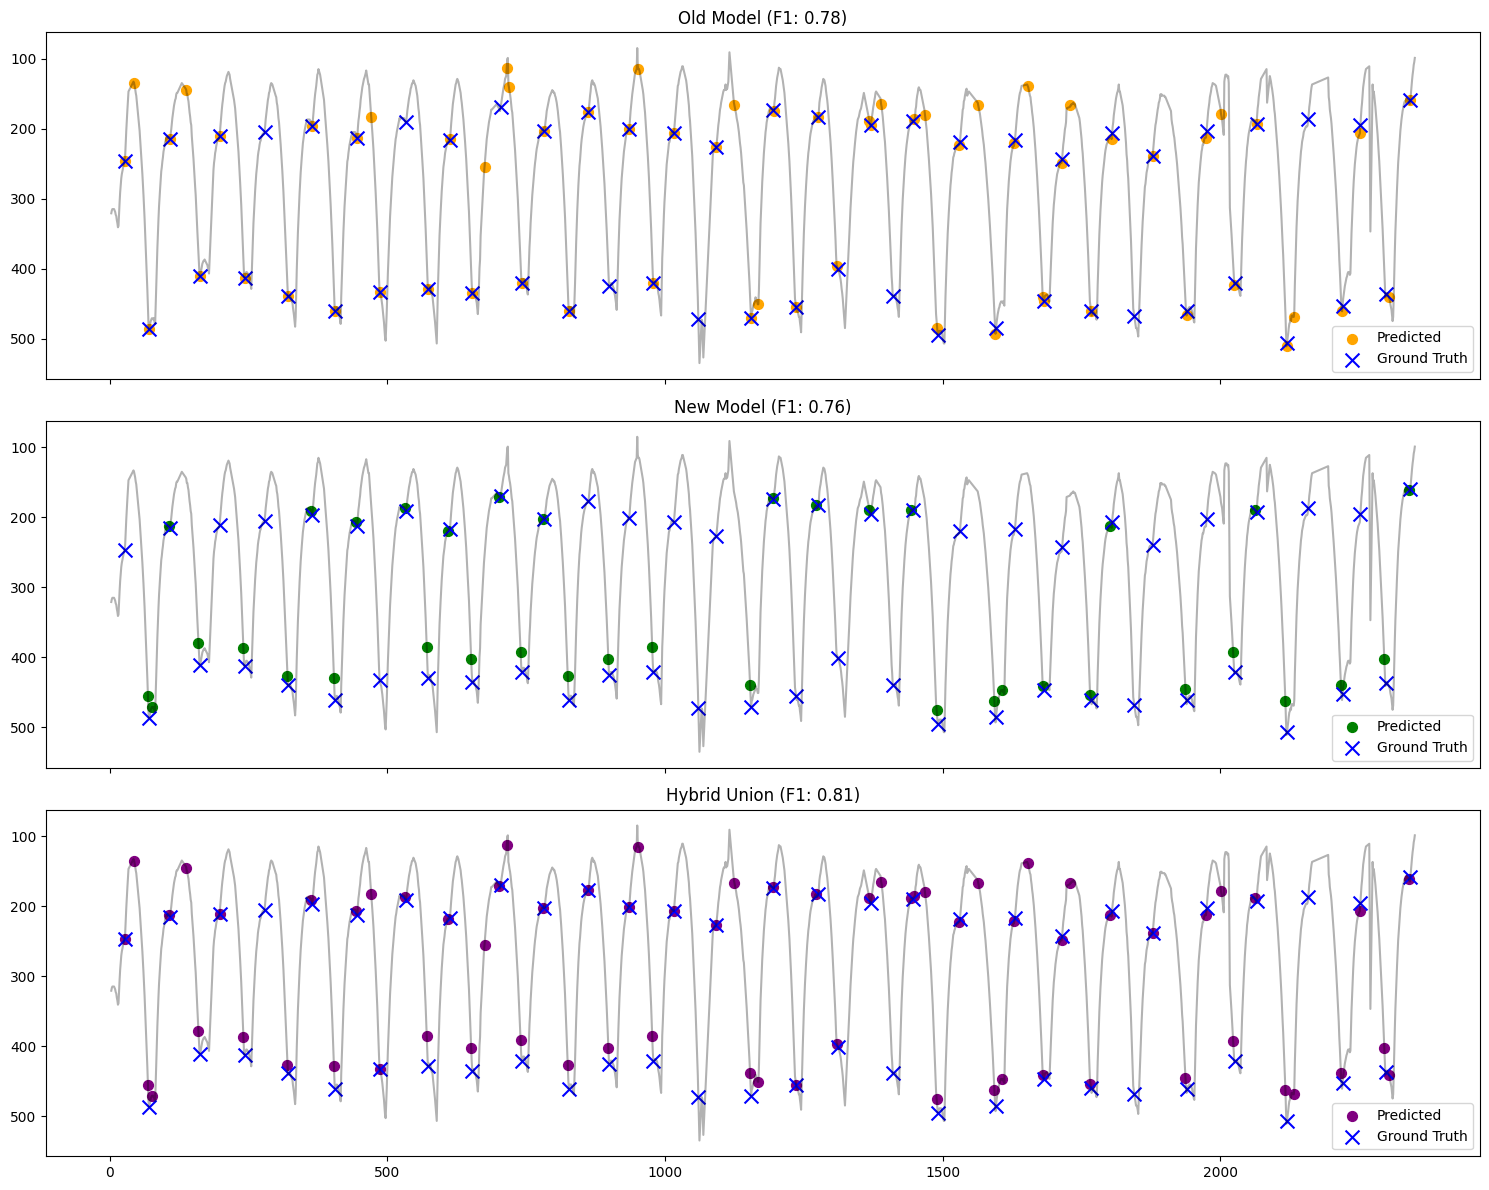

In [16]:
# ==========================================
# 1. CLASS DEFINITIONS
# ==========================================

# --- NEW MODEL (Context Aware) ---
class ML_BounceDetector:
    def __init__(self, model_path, fps=30):
        self.model = joblib.load(model_path)
        self.fps = fps
        self.offset_correction = -2
        
    def predict(self, ball_track, player_track_input):
        # 1. Preprocess Ball
        y_raw = [p[1] if p is not None else np.nan for p in ball_track]
        x_raw = [p[0] if p is not None else np.nan for p in ball_track]
        y_filled = pd.Series(y_raw).interpolate(method='linear', limit_direction='both').values
        x_filled = pd.Series(x_raw).interpolate(method='linear', limit_direction='both').values
        y_smooth = savgol_filter(y_filled, 3, 2)
        x_smooth = savgol_filter(x_filled, 3, 2)
        
        vy = np.gradient(y_smooth)
        vx = np.gradient(x_smooth)
        ay = np.gradient(vy)
        
        # 2. Preprocess Players
        if isinstance(player_track_input, str):
            df_players = pd.read_csv(player_track_input)
        else:
            df_players = player_track_input
            
        p1_locs = df_players[['p1_x', 'p1_y']].fillna(99999).values
        p2_locs = df_players[['p2_x', 'p2_y']].fillna(99999).values
        
        candidates, _ = find_peaks(y_smooth, distance=3, prominence=0.2)
        confirmed_bounces = []
        
        for idx in candidates:
            if idx < 3 or idx >= len(y_smooth) - 3: continue
            
            # Physics
            y_pos = y_smooth[idx]
            vy_in, vy_out = np.mean(vy[idx-3:idx]), np.mean(vy[idx:idx+3])
            vx_in, vx_out = np.mean(vx[idx-3:idx]), np.mean(vx[idx:idx+3])
            raw_force = -ay[idx]
            speed_in = np.sqrt(vx_in**2 + vy_in**2)
            speed_out = np.sqrt(vx_out**2 + vy_out**2)
            energy_ratio = speed_out / (speed_in + 1e-6)
            
            vec_in, vec_out = np.array([vx_in, vy_in]), np.array([vx_out, vy_out])
            impact_angle = np.dot(vec_in, vec_out) / ((speed_in * speed_out) + 1e-6)
            weighted_force = raw_force * (1000 / (y_pos + 10))
            
            # Context
            ball_pos = np.array([x_filled[idx], y_filled[idx]])
            min_dist = min(distance.euclidean(ball_pos, p1_locs[idx]), distance.euclidean(ball_pos, p2_locs[idx]))
            is_near_player = 1 if min_dist < 80 else 0
            
            features = [y_pos, vy_in, vy_out, raw_force, vx_in, vx_out, abs(vx_in - vx_out), 
                        1 if (vx_in * vx_out) < -0.5 else 0, speed_in, energy_ratio, impact_angle, 
                        weighted_force, min_dist, is_near_player]
            
            if self.model.predict([features])[0] == 1:
                confirmed_bounces.append(idx + self.offset_correction)
                
        return sorted(list(set(confirmed_bounces)))
# --- OLD MODEL (Original Logic) ---
class BounceDetector:
    def __init__(self, path_model=None):
        self.model = ctb.CatBoostRegressor()
        self.threshold = 0.45
        if path_model:
            self.model.load_model(path_model)
    
    def prepare_features(self, x_ball, y_ball):
        labels = pd.DataFrame({'frame': range(len(x_ball)), 'x-coordinate': x_ball, 'y-coordinate': y_ball})
        num = 3
        eps = 1e-15
        for i in range(1, num):
            labels['x_lag_{}'.format(i)] = labels['x-coordinate'].shift(i)
            labels['x_lag_inv_{}'.format(i)] = labels['x-coordinate'].shift(-i)
            labels['y_lag_{}'.format(i)] = labels['y-coordinate'].shift(i)
            labels['y_lag_inv_{}'.format(i)] = labels['y-coordinate'].shift(-i) 
            labels['x_diff_{}'.format(i)] = abs(labels['x_lag_{}'.format(i)] - labels['x-coordinate'])
            labels['y_diff_{}'.format(i)] = labels['y_lag_{}'.format(i)] - labels['y-coordinate']
            labels['x_diff_inv_{}'.format(i)] = abs(labels['x_lag_inv_{}'.format(i)] - labels['x-coordinate'])
            labels['y_diff_inv_{}'.format(i)] = labels['y_lag_inv_{}'.format(i)] - labels['y-coordinate']
            labels['x_div_{}'.format(i)] = abs(labels['x_diff_{}'.format(i)]/(labels['x_diff_inv_{}'.format(i)] + eps))
            labels['y_div_{}'.format(i)] = labels['y_diff_{}'.format(i)]/(labels['y_diff_inv_{}'.format(i)] + eps)

        for i in range(1, num):
            labels = labels[labels['x_lag_{}'.format(i)].notna()]
            labels = labels[labels['x_lag_inv_{}'.format(i)].notna()]
        labels = labels[labels['x-coordinate'].notna()] 
        
        colnames = ['x_diff_{}'.format(i) for i in range(1, num)] + ['x_diff_inv_{}'.format(i) for i in range(1, num)] + \
                   ['x_div_{}'.format(i) for i in range(1, num)] + ['y_diff_{}'.format(i) for i in range(1, num)] + \
                   ['y_diff_inv_{}'.format(i) for i in range(1, num)] + ['y_div_{}'.format(i) for i in range(1, num)]
        return labels[colnames], list(labels['frame'])
    
    def predict(self, x_ball, y_ball, smooth=True):
        if smooth: x_ball, y_ball = self.smooth_predictions(x_ball, y_ball)
        features, num_frames = self.prepare_features(x_ball, y_ball)
        preds = self.model.predict(features)
        ind_bounce = np.where(preds > self.threshold)[0]
        if len(ind_bounce) > 0: ind_bounce = self.postprocess(ind_bounce, preds)
        return sorted(list(set([num_frames[x] for x in ind_bounce])))
    
    def smooth_predictions(self, x_ball, y_ball):
        is_none = [int(x is None) for x in x_ball]
        for num in range(5, len(x_ball)-1):
            if not x_ball[num] and sum(is_none[num-5:num]) == 0:
                x_ext, y_ext = self.extrapolate(x_ball[num-5:num], y_ball[num-5:num])
                x_ball[num], y_ball[num] = x_ext, y_ext
                is_none[num] = 0
        return x_ball, y_ball

    def extrapolate(self, x_coords, y_coords):
        xs = list(range(len(x_coords)))
        return float(CubicSpline(xs, x_coords, bc_type='natural')(len(x_coords))), float(CubicSpline(xs, y_coords, bc_type='natural')(len(x_coords)))

    def postprocess(self, ind_bounce, preds):
        filtered = [ind_bounce[0]]
        for i in range(1, len(ind_bounce)):
            if (ind_bounce[i] - ind_bounce[i-1]) != 1: filtered.append(ind_bounce[i])
            elif preds[ind_bounce[i]] > preds[ind_bounce[i-1]]: filtered[-1] = ind_bounce[i]
        return filtered

# --- 2. EVALUATION FUNCTION ---
def evaluate_bounces(gt_frames, pred_frames, tolerance=5):
    gt = np.sort(gt_frames)
    pred = np.sort(pred_frames)
    tp, fp, fn = [], [], []
    matched_gt = set()
    
    for p in pred:
        dists = np.abs(gt - p)
        if len(dists) == 0:
            fp.append(p)
            continue
        min_dist_idx = np.argmin(dists)
        if dists[min_dist_idx] <= tolerance:
            if min_dist_idx not in matched_gt:
                tp.append(p)
                matched_gt.add(min_dist_idx)
            else:
                fp.append(p)
        else:
            fp.append(p)
            
    for i in range(len(gt)):
        if i not in matched_gt:
            fn.append(gt[i])
            
    precision = len(tp)/(len(tp)+len(fp)) if (len(tp)+len(fp))>0 else 0
    recall = len(tp)/(len(tp)+len(fn)) if (len(tp)+len(fn))>0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0
    
    return {"TP": len(tp), "FP": len(fp), "FN": len(fn), "Precision": precision, "Recall": recall, "F1": f1}, tp, fp, fn

# ==========================================
# 2. HELPER: MERGE PREDICTIONS (UNION)
# ==========================================
def merge_predictions(primary_preds, secondary_preds, tolerance=5):
    """
    Takes predictions from two models. 
    1. Keeps ALL primary predictions (High Precision).
    2. Adds secondary predictions ONLY if they are far from existing ones (Recall Boost).
    """
    final_preds = sorted(list(primary_preds))
    
    for cand in secondary_preds:
        # Check if this candidate is close to any existing confirmed bounce
        # using numpy broadcasting for speed
        if len(final_preds) == 0:
            final_preds.append(cand)
            continue
            
        dists = np.abs(np.array(final_preds) - cand)
        if np.min(dists) > tolerance:
            # It's a new bounce that the primary model missed!
            final_preds.append(cand)
            
    return sorted(final_preds)

# ==========================================
# 3. EXECUTION
# ==========================================

# Load Data
df_track = pd.read_csv(NEW_TRACK_PATH)
df_gt = pd.read_csv(GT_PATH)
gt_frames = df_gt['frame'].values - FRAME_SHIFT
gt_frames = gt_frames[gt_frames >= 0]

# Prepare Inputs
ball_track = [(r['x_pixel'] if not pd.isna(r['x_pixel']) else None, r['y_pixel'] if not pd.isna(r['y_pixel']) else None) for _, r in df_track.iterrows()]
x_ball = [p[0] for p in ball_track]
y_ball = [p[1] for p in ball_track]

# --- RUN MODEL A (OLD) ---
print("Running Old Detector...")
old_detector = BounceDetector(path_model=MODEL_PATH_OLD)
preds_old = old_detector.predict(list(x_ball), list(y_ball), smooth=True)

# --- RUN MODEL B (NEW) ---
print("Running New Detector...")
new_detector = ML_BounceDetector(MODEL_PATH_NEW)
preds_new = new_detector.predict(ball_track, PLAYER_PATH)

# --- RUN HYBRID (MERGE) ---
print("Merging Predictions...")
preds_hybrid = merge_predictions(preds_new, preds_old, tolerance=5)

# ==========================================
# 4. EVALUATION & PLOTTING
# ==========================================
def get_metrics(gt, pred, tol=5):
    metrics, _, _, _ = evaluate_bounces(gt, pred, tol)
    return metrics

m_old = get_metrics(gt_frames, preds_old)
m_new = get_metrics(gt_frames, preds_new)
m_hyb = get_metrics(gt_frames, preds_hybrid)

# Create Comparison Table
results = pd.DataFrame([m_old, m_new, m_hyb], index=['Old Model', 'New Model', 'Hybrid'])
print("\n--- MODEL COMPARISON ---")
print(results[['Precision', 'Recall', 'F1', 'TP', 'FP', 'FN']])

# PLOTTING
y_filled = pd.Series(y_ball).interpolate().values
y_smooth = savgol_filter(y_filled, 3, 2)

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

def plot_model(ax, title, preds, color):
    ax.plot(y_smooth, color='black', alpha=0.3)
    ax.scatter(preds, y_smooth[preds], color=color, s=50, label='Predicted')
    ax.scatter(gt_frames, y_smooth[gt_frames], color='blue', marker='x', s=100, label='Ground Truth')
    ax.set_title(title)
    ax.legend()
    ax.invert_yaxis()

plot_model(axes[0], f"Old Model (F1: {m_old['F1']:.2f})", preds_old, 'orange')
plot_model(axes[1], f"New Model (F1: {m_new['F1']:.2f})", preds_new, 'green')
plot_model(axes[2], f"Hybrid Union (F1: {m_hyb['F1']:.2f})", preds_hybrid, 'purple')

plt.tight_layout()
plt.show()

In [17]:
def smart_ensemble_v2(primary_preds, secondary_preds, ball_track, player_path, 
                      safe_dist=60, net_range=(150, 180)):
    """
    Combines models with two filters:
    1. PLAYER FILTER: Rejects hits close to players (< safe_dist).
    2. NET FILTER: Rejects hits on the net tape (within net_range).
    """
    # Load Player Data
    if isinstance(player_path, str):
        df_p = pd.read_csv(player_path)
    else:
        df_p = player_path
        
    p1_locs = df_p[['p1_x', 'p1_y']].fillna(99999).values
    p2_locs = df_p[['p2_x', 'p2_y']].fillna(99999).values
    
    # 1. Start with Trustworthy Primary Preds (New Model)
    final_set = set(primary_preds)
    
    # 2. Filter Secondary Candidates (Old Model)
    for frame in secondary_preds:
        
        # A. Redundancy Check (Skip if New Model already found it)
        is_covered = False
        for existing in final_set:
            if abs(existing - frame) <= 5:
                is_covered = True
                break
        if is_covered: continue
            
        # --- B. CONTEXT CHECKS ---
        if frame < len(ball_track):
            ball_x, ball_y = ball_track[frame]
            
            # Safety: If track is lost, ignore to maintain precision
            if ball_x is None: continue 
            
            # --- FILTER 1: NET ZONE ---
            # If the bounce is right on the net line, it's likely a net hit, not a ground bounce.
            if net_range[0] <= ball_y <= net_range[1]:
                continue # Reject (Likely Net Hit)
                
            # --- FILTER 2: PLAYER DISTANCE ---
            ball_pos = np.array([ball_x, ball_y])
            d1 = distance.euclidean(ball_pos, p1_locs[frame])
            d2 = distance.euclidean(ball_pos, p2_locs[frame])
            min_dist = min(d1, d2)
            
            # If it's far from players, it's a valid bounce recovery
            if min_dist > safe_dist:
                final_set.add(frame)
    
    return sorted(list(final_set))

# ==========================================
# 2. EXECUTE & COMPARE
# ==========================================

# Tuned parameters based on your error log
BEST_SAFE_DIST = 60
NET_ZONE = (150, 180) # Pixels (Approx net location in 360p)

print(f"Running Smart Ensemble V2...")
print(f" - Player Safe Dist: > {BEST_SAFE_DIST}px")
print(f" - Net Reject Zone:  Y={NET_ZONE}")

preds_v2 = smart_ensemble_v2(preds_new, preds_old, ball_track, PLAYER_PATH, 
                             safe_dist=BEST_SAFE_DIST, 
                             net_range=NET_ZONE)

# Evaluate
m_v2 = get_metrics(gt_frames, preds_v2)

# Show improvement
results_v2 = pd.DataFrame([m_old, m_new, m_v2], 
                          index=['Old Model', 'New Model', 'Ensemble V2 (Net Filter)'])

print("\n--- PERFORMANCE EVOLUTION ---")
print(results_v2[['Precision', 'Recall', 'F1', 'TP', 'FP', 'FN']])

Running Smart Ensemble V2...
 - Player Safe Dist: > 60px
 - Net Reject Zone:  Y=(150, 180)

--- PERFORMANCE EVOLUTION ---
                          Precision    Recall        F1  TP  FP  FN
Old Model                  0.723077  0.854545  0.783333  47  18   8
New Model                  0.945946  0.636364  0.760870  35   2  20
Ensemble V2 (Net Filter)   0.854545  0.854545  0.854545  47   8   8


In [18]:

class SmartBounceEnsemble:
    def __init__(self, primary_model, secondary_model, safe_dist=60, net_zone=(150, 180), cooldown=15):
        """
        :param primary_model: The High-Precision New Model (ML_BounceDetector)
        :param secondary_model: The High-Recall Old Model (BounceDetector)
        :param safe_dist: Minimum distance (px) from a player to accept a secondary bounce.
        :param net_zone: Tuple (y_min, y_max) defining the net area to reject hits.
        :param cooldown: Minimum frames between two valid bounces (removes 'double detection' noise).
        """
        self.primary = primary_model
        self.secondary = secondary_model
        self.safe_dist = safe_dist
        self.net_zone = net_zone
        self.cooldown = cooldown
        
    def predict(self, ball_track, player_track_input):
        # 1. Run Models
        print("   -> Running Primary Model (Precision)...")
        preds_primary = set(self.primary.predict(ball_track, player_track_input))
        
        print("   -> Running Secondary Model (Recall)...")
        x_ball = [p[0] if p is not None else None for p in ball_track]
        y_ball = [p[1] if p is not None else None for p in ball_track]
        preds_secondary = self.secondary.predict(x_ball, y_ball, smooth=True)
        
        # 2. Load Player Data
        if isinstance(player_track_input, str):
            df_p = pd.read_csv(player_track_input)
        else:
            df_p = player_track_input
        
        # Optimize Data Access
        p1_locs = df_p[['p1_x', 'p1_y']].fillna(99999).values
        p2_locs = df_p[['p2_x', 'p2_y']].fillna(99999).values
        
        # 3. Merge & Filter
        candidates = []
        
        # A. Add ALL Primary Preds (High Trust)
        for p in preds_primary:
            candidates.append({'frame': p, 'source': 'primary'})
            
        # B. Add Valid Secondary Preds
        for frame in preds_secondary:
            # Skip if very close to a Primary (Redundancy check)
            # We use a small window (5 frames) just to check "is this the same event?"
            if any(abs(frame - p) <= 5 for p in preds_primary):
                continue

            # Context Filter
            if frame < len(ball_track):
                ball_x, ball_y = ball_track[frame]
                if ball_x is None: continue 
                
                # Net Filter
                if self.net_zone[0] <= ball_y <= self.net_zone[1]:
                    continue 
                    
                # Player Distance Filter
                ball_pos = np.array([ball_x, ball_y])
                d1 = distance.euclidean(ball_pos, p1_locs[frame])
                d2 = distance.euclidean(ball_pos, p2_locs[frame])
                
                if min(d1, d2) > self.safe_dist:
                    candidates.append({'frame': frame, 'source': 'secondary'})
        
        # 4. Temporal Cooldown (The User's Insight)
        # Sort by frame order
        candidates.sort(key=lambda x: x['frame'])
        
        final_bounces = []
        if not candidates: return []
        
        # We process the sorted list and enforce the cooldown
        last_valid_frame = -999
        last_source = None
        
        for cand in candidates:
            frame = cand['frame']
            source = cand['source']
            
            # Calculate time since last bounce
            diff = frame - last_valid_frame
            
            if diff > self.cooldown:
                # Valid new bounce
                final_bounces.append(frame)
                last_valid_frame = frame
                last_source = source
            else:
                # CONFLICT: We have two bounces too close together.
                # Logic: If the current one is PRIMARY and the last one was SECONDARY,
                # we should swap them (trust Primary more).
                if source == 'primary' and last_source == 'secondary':
                    print(f"      [Cooldown Swap] Replaced secondary {last_valid_frame} with primary {frame}")
                    final_bounces.pop() # Remove the weak previous one
                    final_bounces.append(frame)
                    last_valid_frame = frame
                    last_source = source
                else:
                    print(f"      [Cooldown Suppress] Ignored {frame} ({source}) - too close to {last_valid_frame}")
                    
        return sorted(final_bounces)

# ==========================================
# EXECUTE V3
# ==========================================

# 15 frames = 0.5 seconds at 30fps. 
# It is physically impossible to have two bounces on opposite courts in < 0.5s.
COOLDOWN_FRAMES = 15 

ensemble_v3 = SmartBounceEnsemble(
    new_detector, 
    old_detector, 
    safe_dist=60, 
    net_zone=(150, 180),
    cooldown=COOLDOWN_FRAMES
)

print(f"\nRunning Ensemble V3 with Cooldown ({COOLDOWN_FRAMES} frames)...")
preds_v3 = ensemble_v3.predict(ball_track, PLAYER_PATH)

# Compare Results
m_v3 = get_metrics(gt_frames, preds_v3)

results_v3 = pd.DataFrame([m_old, m_new, m_v2, m_v3], 
                          index=['Old Model', 'New Model', 'Ensemble V2', 'Ensemble V3 (Cooldown)'])

print("\n--- FINAL PERFORMANCE ---")
print(results_v3[['Precision', 'Recall', 'F1', 'TP', 'FP', 'FN']])


Running Ensemble V3 with Cooldown (15 frames)...
   -> Running Primary Model (Precision)...
   -> Running Secondary Model (Recall)...
      [Cooldown Suppress] Ignored 77 (primary) - too close to 69
      [Cooldown Suppress] Ignored 1168 (secondary) - too close to 1153
      [Cooldown Suppress] Ignored 1606 (primary) - too close to 1593
      [Cooldown Suppress] Ignored 2132 (secondary) - too close to 2117
      [Cooldown Suppress] Ignored 2303 (secondary) - too close to 2295

--- FINAL PERFORMANCE ---
                        Precision    Recall        F1  TP  FP  FN
Old Model                0.723077  0.854545  0.783333  47  18   8
New Model                0.945946  0.636364  0.760870  35   2  20
Ensemble V2              0.854545  0.854545  0.854545  47   8   8
Ensemble V3 (Cooldown)   0.940000  0.854545  0.895238  47   3   8


In [21]:

def create_heatmap_overlay_video(video_path, output_path, df_data, homography_matrices):
    # 1. Setup Video
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # 2. Setup Robust Minimap
    # We rebuild the court manually with THICKER lines for visibility
    court_ref = CourtReference()
    
    # Create blank canvas (Height ~3500, Width ~1600 based on standard logic)
    # We use the dimensions from the class
    base_h = court_ref.court_total_height
    base_w = court_ref.court_total_width
    court_bg = np.zeros((base_h, base_w, 3), dtype=np.uint8)
    
    # Drawing Settings for Overlay
    # We use 25px thickness so when resized by 10x, it's still ~2.5px visible
    LINE_THICKNESS = 25 
    LINE_COLOR = (255, 255, 255) # Pure White
    
    # Helper to draw lines from the reference points
    def draw_line(img, pts):
        # pts is ((x1, y1), (x2, y2))
        pt1 = (int(pts[0][0]), int(pts[0][1]))
        pt2 = (int(pts[1][0]), int(pts[1][1]))
        cv2.line(img, pt1, pt2, LINE_COLOR, LINE_THICKNESS)

    # Draw Standard Lines
    draw_line(court_bg, court_ref.baseline_top)
    draw_line(court_bg, court_ref.baseline_bottom)
    draw_line(court_bg, court_ref.net)
    draw_line(court_bg, court_ref.top_inner_line)
    draw_line(court_bg, court_ref.bottom_inner_line)
    draw_line(court_bg, court_ref.left_court_line)
    draw_line(court_bg, court_ref.right_court_line)
    draw_line(court_bg, court_ref.left_inner_line)
    draw_line(court_bg, court_ref.right_inner_line)
    draw_line(court_bg, court_ref.middle_line)
    
    # Draw Center Marks (The "missing" parts on baselines)
    # Top Mark
    cv2.line(court_bg, (int(832.5), int(561)), (int(832.5), int(580)), LINE_COLOR, LINE_THICKNESS)
    # Bottom Mark
    cv2.line(court_bg, (int(832.5), int(2935)), (int(832.5), int(2910)), LINE_COLOR, LINE_THICKNESS)

    # Resize settings
    mini_h = int(height * 0.35) 
    scale = mini_h / base_h
    mini_w = int(base_w * scale)
    
    print(f"Generating Overlay Video with Enhanced Lines: {output_path}...")
    
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        # --- A. PREPARE MINIMAP ---
        minimap = court_bg.copy()
        dots_layer = np.zeros_like(minimap)
        
        # Get bounces
        current_bounces = df_data[df_data['frame'] <= frame_idx]
        
        for _, bounce in current_bounces.iterrows():
            mx = (bounce['x_meters'] * 100) + 832.5
            my = (bounce['y_meters'] * 100) + 1748
            color = (0, 255, 0) if bounce['side'] == 'Deuce' else (0, 0, 255)
            # Draw larger dots for high-res map
            cv2.circle(dots_layer, (int(mx), int(my)), 50, color, -1)

        # Blend dots onto court
        minimap = cv2.addWeighted(minimap, 1.0, dots_layer, 0.6, 0)
        
        # --- B. RESIZE & OVERLAY ---
        # Resize using AREA interpolation which is better for shrinking lines
        minimap_small = cv2.resize(minimap, (mini_w, mini_h), interpolation=cv2.INTER_AREA)
        
        margin = 20
        x1 = width - mini_w - margin
        y1 = margin
        x2 = x1 + mini_w
        y2 = y1 + mini_h
        
        # Safe Check for bounds
        if y2 < height and x2 < width:
            roi = frame[y1:y2, x1:x2]
            blended = cv2.addWeighted(roi, 0.3, minimap_small, 0.7, 0)
            frame[y1:y2, x1:x2] = blended
            cv2.rectangle(frame, (x1-2, y1-2), (x2+2, y2+2), (255, 255, 255), 2)

        out.write(frame)
        frame_idx += 1
        
    cap.release()
    out.release()
    print("Done.")

def create_dual_validation_video(video_path, output_path, df_data1, df_data2, ground_truth_path, label1="Model A", label2="Model B", tolerance=5):
    """
    Creates a video with two minimaps (Top-Right & Bottom-Right).
    Both maps are validated against the Ground Truth.
    
    - Green Dot: Prediction matches a ground truth frame (within tolerance).
    - Red Dot: Prediction is a False Positive.
    """
    
    # --- 1. PRE-PROCESS DATA & COLORS ---
    print("Pre-processing validation data...")
    
    # Load Ground Truth
    gt_df = pd.read_csv(ground_truth_path)
    gt_frames = set(gt_df['frame'].tolist())
    
    # Helper to assign colors to a dataframe
    def validate_predictions(df, gt_set, tol):
        colors = []
        statuses = [] # To store 'Correct' or 'Wrong' for counting
        
        for _, row in df.iterrows():
            pred_frame = int(row['frame'])
            
            # Check if prediction is within tolerance of ANY ground truth frame
            # Range: [frame - tol, frame + tol]
            is_match = False
            for t in range(pred_frame - tol, pred_frame + tol + 1):
                if t in gt_set:
                    is_match = True
                    break
            
            if is_match:
                colors.append((0, 255, 0)) # Green
                statuses.append('Correct')
            else:
                colors.append((0, 0, 255)) # Red
                statuses.append('Wrong')
                
        df = df.copy()
        df['color'] = colors
        df['status'] = statuses
        return df

    # Validate both datasets
    df1_valid = validate_predictions(df_data1, gt_frames, tolerance)
    df2_valid = validate_predictions(df_data2, gt_frames, tolerance)

    # --- 2. SETUP VIDEO ---
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # --- 3. SETUP COURT BACKGROUND ---
    # Standard court dimensions
    base_h = 3500 # Approx standard for high-res mapping
    base_w = 1600
    court_bg = np.zeros((base_h, base_w, 3), dtype=np.uint8)
    
    LINE_THICKNESS = 25
    LINE_COLOR = (255, 255, 255)
    
    # Simple line drawer
    def dline(y1, x1, y2, x2):
        cv2.line(court_bg, (int(x1), int(y1)), (int(x2), int(y2)), LINE_COLOR, LINE_THICKNESS)

    # Draw Manual Court (Adjust coordinates if your CourtReference class differs)
    # Outer box
    dline(0, 0, base_h, 0) # Left
    dline(0, base_w, base_h, base_w) # Right
    dline(0, 0, 0, base_w) # Top
    dline(base_h, 0, base_h, base_w) # Bottom
    # Inner lines
    dline(1750, 0, 1750, base_w) # Net
    dline(561, 0, 561, base_w) # Top Service
    dline(2935, 0, 2935, base_w) # Bottom Service
    dline(0, 274, base_h, 274) # Left Singles
    dline(0, 1326, base_h, 1326) # Right Singles
    dline(561, 800, 2935, 800) # Center Service

    # Resize settings for the overlay
    mini_h = int(height * 0.30)
    scale = mini_h / base_h
    mini_w = int(base_w * scale)
    
    print(f"Generating Dual Validation Video: {output_path}...")

    # --- 4. RENDER LOOP ---
    
    def generate_minimap_with_stats(current_data, label_text):
        """
        Draws the map, the dots, and a header with stats.
        """
        # A. Draw Dots
        minimap = court_bg.copy()
        dots_layer = np.zeros_like(minimap)
        
        for _, row in current_data.iterrows():
            # Coordinate Transform (Assuming meters -> court units)
            # Adjust these constants if your coordinate system is different
            mx = (row['x_meters'] * 100) + 800
            my = (row['y_meters'] * 100) + 1750
            
            color = row['color'] # Pre-calculated Green/Red
            cv2.circle(dots_layer, (int(mx), int(my)), 50, color, -1)
            
        minimap = cv2.addWeighted(minimap, 1.0, dots_layer, 0.7, 0)
        
        # B. Resize
        minimap_small = cv2.resize(minimap, (mini_w, mini_h), interpolation=cv2.INTER_AREA)
        
        # C. Add Header with Stats
        # Calculate stats for the data shown SO FAR
        correct_count = len(current_data[current_data['status'] == 'Correct'])
        wrong_count = len(current_data[current_data['status'] == 'Wrong'])
        
        header_h = 40
        final_map = np.zeros((mini_h + header_h, mini_w, 3), dtype=np.uint8)
        final_map[header_h:, :] = minimap_small # Place map below header
        
        # Draw Header Text
        # "Model A: 5 (OK) | 2 (X)"
        text = f"{label_text}: {correct_count} (OK) | {wrong_count} (X)"
        cv2.putText(final_map, text, (5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        
        return final_map

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        # Slice data up to current frame
        data1_now = df1_valid[df1_valid['frame'] <= frame_idx]
        data2_now = df2_valid[df2_valid['frame'] <= frame_idx]
        
        # Generate Maps
        map1 = generate_minimap_with_stats(data1_now, label1)
        map2 = generate_minimap_with_stats(data2_now, label2)
        
        # Dimensions
        mh, mw, _ = map1.shape
        margin = 20
        
        # --- OVERLAY 1: TOP RIGHT ---
        x1_top = width - mw - margin
        y1_top = margin
        x2_top = x1_top + mw
        y2_top = y1_top + mh
        
        if y2_top < height and x2_top < width:
            roi1 = frame[y1_top:y2_top, x1_top:x2_top]
            blended1 = cv2.addWeighted(roi1, 0.3, map1, 0.7, 0)
            frame[y1_top:y2_top, x1_top:x2_top] = blended1
            cv2.rectangle(frame, (x1_top, y1_top), (x2_top, y2_top), (255, 255, 255), 2)

        # --- OVERLAY 2: BOTTOM RIGHT ---
        x1_bot = width - mw - margin
        y1_bot = height - mh - margin
        x2_bot = x1_bot + mw
        y2_bot = y1_bot + mh
        
        if y1_bot > 0 and x2_bot < width:
            roi2 = frame[y1_bot:y2_bot, x1_bot:x2_bot]
            blended2 = cv2.addWeighted(roi2, 0.3, map2, 0.7, 0)
            frame[y1_bot:y2_bot, x1_bot:x2_bot] = blended2
            cv2.rectangle(frame, (x1_bot, y1_bot), (x2_bot, y2_bot), (255, 255, 255), 2)

        out.write(frame)
        frame_idx += 1
        
        if frame_idx % 50 == 0:
            print(f"Processed frame {frame_idx}...")

    cap.release()
    out.release()
    print("Dual Validation Video Done.")
# --- EXECUTION ---

# --- STEP 1: INITIALIZE MODELS ---
# Using the best parameters discovered during your testing
ensemble = SmartBounceEnsemble(
    primary_model=new_detector, 
    secondary_model=old_detector, 
    safe_dist=60, 
    net_zone=(150, 180),
    cooldown=15
)

# --- STEP 2: RUN ENSEMBLE PREDICTION ---
print("Running Smart Ensemble V3 on full video...")

homography_matrices = np.load(MATRICES_PATH, allow_pickle=True)

df_track = pd.read_csv(NEW_TRACK_PATH)
df_gt = pd.read_csv(GT_PATH)
gt_frames = df_gt['frame'].values - FRAME_SHIFT
gt_frames = gt_frames[gt_frames >= 0]

# Prepare Inputs
ball_track = [(r['x_pixel'] if not pd.isna(r['x_pixel']) else None, r['y_pixel'] if not pd.isna(r['y_pixel']) else None) for _, r in df_track.iterrows()]

final_bounce_frames1 = ensemble.predict(ball_track, PLAYER_PATH)
final_bounce_frames2 = old_detector.predict(list(x_ball), list(y_ball), smooth=True)


# --- STEP 3: EXTRACT COORDINATES ---
# Convert frame indices to real-world meters for the overlay
extractor = PreciseCoordinateExtractor()

df_refined1 = extractor.get_coordinates(final_bounce_frames1, ball_track, homography_matrices)

df_refined2 = extractor.get_coordinates(final_bounce_frames2, ball_track, homography_matrices)

# --- STEP 4: GENERATE OVERLAY VIDEO ---
output_filename = 'match_heatmap_comparison.mp4'
# create_heatmap_overlay_video(
#     VIDEO_PATH8, 
#     output_filename, 
#     df_refined1, 
#     homography_matrices
# )

create_dual_validation_video(
    VIDEO_PATH8, 
    output_filename, 
    df_refined1, 
    df_refined2,
    GT_PATH,
    label1="Ensemble", 
    label2="Old Model"
)

print(f"Success! Final overlay saved as: {output_filename}")

Running Smart Ensemble V3 on full video...
   -> Running Primary Model (Precision)...
   -> Running Secondary Model (Recall)...
      [Cooldown Suppress] Ignored 77 (primary) - too close to 69
      [Cooldown Suppress] Ignored 1168 (secondary) - too close to 1153
      [Cooldown Suppress] Ignored 1606 (primary) - too close to 1593
      [Cooldown Suppress] Ignored 2132 (secondary) - too close to 2117
      [Cooldown Suppress] Ignored 2303 (secondary) - too close to 2295
Extracting coordinates for detected bounces...
Extracting coordinates for detected bounces...
Pre-processing validation data...
Generating Dual Validation Video: match_heatmap_comparison.mp4...
Processed frame 50...
Processed frame 100...
Processed frame 150...
Processed frame 200...
Processed frame 250...
Processed frame 300...
Processed frame 350...
Processed frame 400...
Processed frame 450...
Processed frame 500...
Processed frame 550...
Processed frame 600...
Processed frame 650...
Processed frame 700...
Processed 